# Bivariate Moran's I — LR spatial co-localization sanity check

Sanity check for the JS ligand-receptor analysis in `03_distance_tls_bronchi_vis.ipynb`. Uses Liana's bivariate Moran's I to test whether the same L-R pairs rank highly under an independent spatial co-expression metric.

**Approach:** Run bivariate Moran's I (ligand: all cells, receptor: all cells) per L-R pair on the full tissue. Extract per-cell local scores. For each CD4 comparison (Th0 vs Th2 etc.), compute ΔMean local score between subtypes and compare with ΔJS from notebook 03.

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml) + `pip install liana`

In [1]:
from pathlib import Path
import sys
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import anndata
import scanpy as sc
from scipy.stats import spearmanr

## Local file info

In [2]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
out_dir = os.path.join(BASE_OUTDIR, "downstream_analysis")
plot_out_dir = os.path.join(out_dir, 'plots', 'bivariate_morans')
os.makedirs(plot_out_dir, exist_ok=True)

## Install / import liana

liana is not included in the space2 YAML. Install once with:
```
pip install liana
```

In [11]:
import liana as li
print('liana version:', li.__version__)

liana version: 1.10.0


## Load data

Loads the output of `02_distance_tls_bronchi.ipynb` (same as notebook 03).

In [16]:
adata = sc.read_h5ad(os.path.join(out_dir, 'adata_distance.h5ad'))
print(adata)

AnnData object with n_obs × n_vars = 593237 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'sample_label', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'Barcode', 'Age', 'Oxygen', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'Sample', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.15', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.2', 'integrated_snn_res.0.1', 'cluster_high_res', 'CellType', 'leiden_res1', 'CellType_consolidated', '_scvi_batch', '_scvi_labels', 'celltype_scanvi', 'C_scANVI', 'label_scan

In [5]:
df_lr_raw = pd.read_csv(os.path.join(inputs_dir, 'interaction_input_CellChatDB.csv'))
print(df_lr_raw.shape)
df_lr_raw.head(3)

(2021, 12)


,Unnamed: 0,interaction_name,pathway_name,ligand,receptor,agonist,antagonist,co_A_receptor,co_I_receptor,evidence,annotation,interaction_name_2
0,TGFB1_TGFBR1_TGFBR2,TGFB1_TGFBR1_TGFBR2,TGFb,Tgfb1,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: mmu04350,Secreted Signaling,Tgfb1 - (Tgfbr1+Tgfbr2)
1,TGFB2_TGFBR1_TGFBR2,TGFB2_TGFBR1_TGFBR2,TGFb,Tgfb2,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: mmu04350,Secreted Signaling,Tgfb2 - (Tgfbr1+Tgfbr2)
2,TGFB3_TGFBR1_TGFBR2,TGFB3_TGFBR1_TGFBR2,TGFb,Tgfb3,TGFbR1_R2,TGFb agonist,TGFb antagonist,NaN,TGFb inhibition receptor,KEGG: mmu04350,Secreted Signaling,Tgfb3 - (Tgfbr1+Tgfbr2)


## Prepare spatial coordinates

Liana expects `adata.obsm['spatial']`. Xenium coordinates are stored in `obs['x_centroid']` / `obs['y_centroid']`.

In [6]:
if 'spatial' not in adata.obsm:
    adata.obsm['spatial'] = adata.obs[['x_centroid', 'y_centroid']].to_numpy(dtype=float)
    print('Created obsm[spatial] from x_centroid / y_centroid')
else:
    print('obsm[spatial] already present, shape:', adata.obsm['spatial'].shape)

obsm[spatial] already present, shape: (593237, 2)


## Parse CellChatDB into liana resource format

Liana's `li.mt.bivariate()` expects a DataFrame with `ligand` and `receptor` columns (one row per pair). Reuse the `_parse_lr` parsing logic from notebook 03 to expand multi-subunit receptors into individual subunit pairs.

In [7]:
def _parse_lr(name2):
    parts = re.split(r'\s+-\s+', str(name2), maxsplit=1)
    if len(parts) != 2:
        return None
    def genes(s):
        return [g.strip() for g in s.strip().strip('()').split('+') if g.strip()]
    return genes(parts[0]), genes(parts[1])

var_lower = {v.lower(): v for v in adata.var_names}
def _resolve(g):
    return var_lower.get(g.lower())

pairs, seen = [], set()
for name2 in df_lr_raw['interaction_name_2'].dropna():
    parsed = _parse_lr(name2)
    if parsed is None:
        continue
    ligs, recs = parsed
    if len(ligs) != 1:
        continue
    lig = _resolve(ligs[0])
    if lig is None:
        continue
    for rec_raw in recs:
        rec = _resolve(rec_raw)
        if rec is not None and (lig, rec) not in seen:
            seen.add((lig, rec)); pairs.append((lig, rec))

df_resource = pd.DataFrame(pairs, columns=['ligand', 'receptor'])
print(f'{len(df_resource)} L-R pairs with both genes in adata.var_names')
df_resource.head()

269 L-R pairs with both genes in adata.var_names


,ligand,receptor
0,Tgfb1,Tgfbr1
1,Tgfb1,Tgfbr2
2,Tgfb2,Tgfbr1
3,Tgfb2,Tgfbr2
4,Tgfb3,Tgfbr1


## Spatial graph construction

Select bandwidth using `query_bandwidth`, then build a Gaussian spatial weight graph. Target ~10–30 neighbors per cell on average.

In [15]:
# Use day3 sample to select bandwidth — apply same value to both samples
adata_d3 = adata[adata.obs['sample_label'] == 'HDM_day3'].copy()
adata_d3.obsm['spatial'] = adata.obsm['spatial'][adata.obs['sample_label'] == 'HDM_day3']

li.ut.query_bandwidth(adata_d3.obsm['spatial'], start=10, end=100, interval_n=10)

(<plotnine.ggplot.ggplot object at 0x7d4f7e1e9a30>,
    bandwith  neighbours
 0      10.0         3.0
 1      20.0        12.0
 2      30.0        26.0
 3      40.0        45.0
 4      50.0        69.0
 5      60.0        98.0
 6      70.0       133.0
 7      80.0       172.0
 8      90.0       216.0
 9     100.0       266.0)

## Run bivariate Moran's I

Run once per sample on the full tissue. Both ligand and receptor use all cells — no masking. Cell-type comparison is done post-hoc on the per-cell local scores.

In [19]:
ad_d3

AnnData object with n_obs × n_vars = 355812 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'sample_label', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'Barcode', 'Age', 'Oxygen', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'Sample', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.15', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.2', 'integrated_snn_res.0.1', 'cluster_high_res', 'CellType', 'leiden_res1', 'CellType_consolidated', '_scvi_batch', '_scvi_labels', 'celltype_scanvi', 'C_scANVI', 'label_scan

In [20]:
BANDWIDTH = 30
sample_label = 'HDM_day3'
ad_d3 = adata[adata.obs['sample_label'] == sample_label].copy()

li.ut.spatial_neighbors(
    ad_d3,
    bandwidth=BANDWIDTH,
    cutoff=0.1,
    kernel='gaussian',
    set_diag=True,
    spatial_key='spatial',
)

res_d3 = li.mt.bivariate(
    ad_d3,
    resource=df_resource,
    global_name='morans',
    local_name='cosine',
    n_perms=100,
    mask_negatives=True,
    nz_prop=0.05,
    use_raw = False
)
print(type(res_d3))
print(res_d3)

<class 'anndata._core.anndata.AnnData'>
AnnData object with n_obs × n_vars = 355812 × 135
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'sample_label', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'Barcode', 'Age', 'Oxygen', 'percent.mt', 'S.Score', 'G2M.Score', 'Phase', 'Sample', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.15', 'nCount_SCT', 'nFeature_SCT', 'integrated_snn_res.0.2', 'integrated_snn_res.0.1', 'cluster_high_res', 'CellType', 'leiden_res1', 'CellType_consolidated', '_scvi_batch', '_scvi_labels', 'c

In [21]:
# Inspect output structure — check where global stats and local scores live
print('var columns:', res_d3.var.columns.tolist() if hasattr(res_d3, 'var') else 'N/A')
print('obsm keys:', list(res_d3.obsm.keys()) if hasattr(res_d3, 'obsm') else 'N/A')
print('uns keys:', list(res_d3.uns.keys()) if hasattr(res_d3, 'uns') else 'N/A')

var columns: ['ligand', 'receptor', 'ligand_means', 'ligand_props', 'receptor_means', 'receptor_props', 'morans', 'morans_pvals', 'mean', 'std']
obsm keys: ['X_pca', 'X_scANVI', 'X_scVI_refalign', 'X_umap', 'X_umap_scanvi_refalign', 'X_umap_scvi_refalign', 'spatial']
uns keys: ['_scvi_manager_uuid', '_scvi_uuid', 'label_coarse_colors', 'label_coarser_colors', 'label_fine_colors', 'label_medium_colors', 'label_scanvi_colors', 'label_scanvi_refine_colors', 'leiden', 'leiden_scvi_refalign_colors', 'neighbors_scanvi', 'neighbors_scvi_refalign', 'rank_genes_groups', 'sample_colors', 'sample_label_colors', 'umap']


In [22]:
# sample_label = 'HDM_day30'
# ad_d30 = adata[adata.obs['sample_label'] == sample_label].copy()

# li.ut.spatial_neighbors(
#     ad_d30,
#     bandwidth=BANDWIDTH,
#     cutoff=0.1,
#     kernel='gaussian',
#     set_diag=True,
#     spatial_key='spatial',
# )

# res_d30 = li.mt.bivariate(
#     ad_d30,
#     resource=df_resource,
#     global_name='morans',
#     local_name='cosine',
#     n_perms=100,
#     mask_negatives=True,
#     nz_prop=0.05,
# )
# print('day30 done')

## Extract per-cell-type ΔMean local scores

For each L-R pair, compare the distribution of local bivariate Moran's scores between two CD4 subtypes. ΔMean > 0 means subtype A cells sit in regions with higher L-R co-expression than subtype B cells.

**Sign convention:** ΔMean (A−B) > 0 ↔ more co-localized with A. ΔJS (from notebook 03, `celltypes=[A, B]`) > 0 ↔ also more co-localized with A (JS_B < JS_A → B is more co-localized → wait, need to check). The two should be **positively** correlated if methods agree.

In [28]:
def delta_mean_local(res, ct_a, ct_b, celltype_col='label_fine'):
    """
    Compute ΔMean local bivariate score (ct_a - ct_b) per L-R pair.

    res: AnnData returned by li.mt.bivariate()
         res.X  — local scores (n_cells × n_pairs)
         res.var — L-R pair metadata (ligand, receptor, morans, ...)
         res.obs — cell metadata (carries celltype_col from the input adata)
    Returns DataFrame: ligand, receptor, mean_{ct_a}, mean_{ct_b}, delta_mean
    """
    local = res.X
    if hasattr(local, 'toarray'):
        local = local.toarray()
    local = np.asarray(local)   # (n_cells, n_pairs)

    mask_a = (res.obs[celltype_col] == ct_a).to_numpy()
    mask_b = (res.obs[celltype_col] == ct_b).to_numpy()

    mean_a = np.nanmean(local[mask_a], axis=0)
    mean_b = np.nanmean(local[mask_b], axis=0)

    pair_df = res.var[['ligand', 'receptor']].copy()
    pair_df[f'mean_{ct_a}'] = mean_a
    pair_df[f'mean_{ct_b}'] = mean_b
    pair_df['delta_mean'] = mean_a - mean_b
    return pair_df.reset_index(drop=True)

In [29]:
# Day 3 comparisons
dm_th2_d3   = delta_mean_local(res_d3, ct_a='Th0', ct_b='Th2')
dm_treg_d3  = delta_mean_local(res_d3, ct_a='Th0', ct_b='Treg')
dm_th17_d3  = delta_mean_local(res_d3, ct_a='Th0', ct_b='Th17')

# # Day 30 comparison
# dm_th2_d30  = delta_mean_local(res_d30, ct_a='Th0', ct_b='Th2')

print('Day3 Th0 vs Th2 — top pairs by ΔMean:')
dm_th2_d3.sort_values('delta_mean', ascending=False).head(10)[['ligand','receptor','delta_mean']]

Day3 Th0 vs Th2 — top pairs by ΔMean:


,ligand,receptor,delta_mean
134,Itga4,Itgb7,0.186082
115,H2-Ab1,Cd4,0.141002
126,Thy1,Itgb2,0.129319
116,H2-DMb2,Cd4,0.127245
131,Itga4,Vcam1,0.081613
107,Itgb2,Cd226,0.077646
29,Flt3l,Flt3,0.072197
1,Tgfb1,Tgfbr2,0.057415
8,Ccl21a,Ccr7,0.052308
7,Ccl19,Ccr7,0.051934


In [34]:
dm_th2_d3.sort_values('delta_mean', ascending=False).tail(10)[['ligand','receptor','delta_mean']]

,ligand,receptor,delta_mean
48,Lamc2,Itgb1,-0.112244
17,Spp1,Cd44,-0.114662
90,Col4a1,Itgav,-0.116634
99,Cdh1,Itgb1,-0.120560
93,Col4a1,Cd44,-0.123406
91,Fn1,Cd44,-0.146484
58,Col4a1,Itga3,-0.148484
37,Fn1,Itgb1,-0.157289
32,Col4a1,Itga1,-0.169177
33,Col4a1,Itgb1,-0.216015


## Comparison with JS (ΔJS) results

Load ΔJS CSVs written by notebook 03 and compare rank ordering.

In [36]:
# JS CSVs are written to the notebook 03 working directory (downstream_analysis/)
js_dir = os.path.dirname(os.path.abspath(''))  # downstream_analysis/

js_th2_d3  = pd.read_csv('d3_deltaJS_Th2-Th0.csv', index_col=0)
js_treg_d3 = pd.read_csv('d3_deltaJS_Treg-Th0.csv', index_col=0)
js_th17_d3 = pd.read_csv('d3_deltaJS_Th17-Th0.csv', index_col=0)
js_th2_d30 = pd.read_csv('d30_deltaJS_Th2-Th0.csv', index_col=0)

print('JS Th2 vs Th0 day3:', js_th2_d3.shape)
js_th2_d3.head(3)

JS Th2 vs Th0 day3: (205, 12)


,ligand,receptor,JS_Th2,JS_Th0,delta,frac_pos_Th2,frac_pos_Th0,mean_recep_Th2,mean_recep_Th0,mean_lig,n_Th2,n_Th0
0,Ccl20,Ccr6,0.923306,0.597718,0.325588,0.025850,0.340027,0.219128,3.090409,0.116324,735,1494
1,Cxcl13,Cxcr5,0.953370,0.639724,0.313646,0.014966,0.326640,0.124885,2.882173,0.500830,735,1494
2,Ccl19,Ccr7,0.960600,0.678087,0.282513,0.021769,0.202142,0.189070,1.776178,0.425785,735,1494


In [37]:
def compare_js_morans(js_df, dm_df, title,
                      pairs_to_label=None,
                      figsize=(4, 4)):
    """
    Scatter plot of ΔJS (x) vs ΔMean local Moran's R (y) with Spearman r.
    Both metrics: positive = more co-localized with Th0 (or whichever is 'A').
    """
    merged = js_df[['ligand', 'receptor', 'delta']].merge(
        dm_df[['ligand', 'receptor', 'delta_mean']],
        on=['ligand', 'receptor'], how='inner')
    print(f'{len(merged)} shared pairs for {title}')

    r, pval = spearmanr(merged['delta'], merged['delta_mean'])

    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    ax.scatter(merged['delta'], merged['delta_mean'],
               s=8, color='0.5', alpha=0.4, edgecolors='none')

    if pairs_to_label:
        pairs_set = set(pairs_to_label)
        sel = merged[merged.apply(lambda row: (row['ligand'], row['receptor']) in pairs_set, axis=1)]
        ax.scatter(sel['delta'], sel['delta_mean'], s=30, color='firebrick', zorder=3)
        for _, row in sel.iterrows():
            ax.annotate(f"{row['ligand']}\u2192{row['receptor']}",
                        xy=(row['delta'], row['delta_mean']),
                        xytext=(5, 0), textcoords='offset points',
                        fontsize=7, va='center')

    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel('ΔJS (notebook 03)')
    ax.set_ylabel('ΔMean local Moran\'s R')
    ax.set_title(f'{title}\nSpearman r = {r:.3f}, p = {pval:.2e}', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    fig.tight_layout()
    return fig, merged, r

119 shared pairs for Th0 vs Th2 — day 3


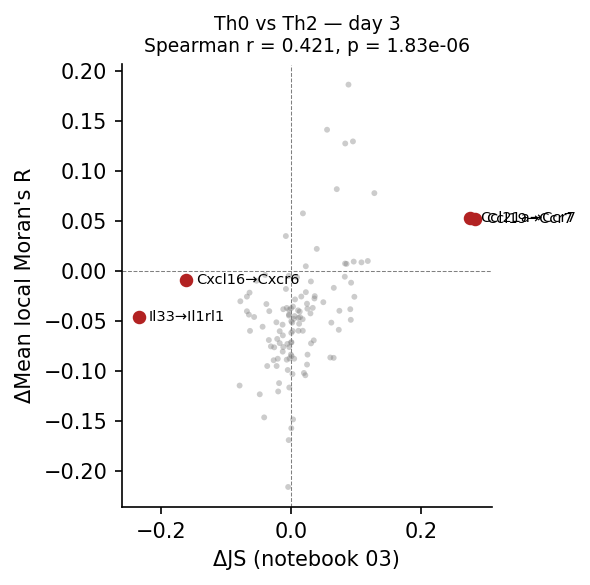

In [38]:
pairs_th2 = [('Ccl19','Ccr7'), ('Ccl21a','Ccr7'), ('Cxcl13','Cxcr5'),
             ('Il21','Il21r'), ('Ccl20','Ccr6'), ('Cxcl16','Cxcr6'),
             ('Il33','Il1rl1'), ('Cdh1','Klrg1'), ('Nmu','Nmur1'), ('Il2','Il2ra')]

fig, merged_th2, r_th2 = compare_js_morans(
    js_th2_d3, dm_th2_d3,
    title='Th0 vs Th2 — day 3',
    pairs_to_label=pairs_th2)
plt.savefig(os.path.join(plot_out_dir, 'compare_JS_morans_Th0vTh2_d3.pdf'),
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

117 shared pairs for Th0 vs Treg — day 3


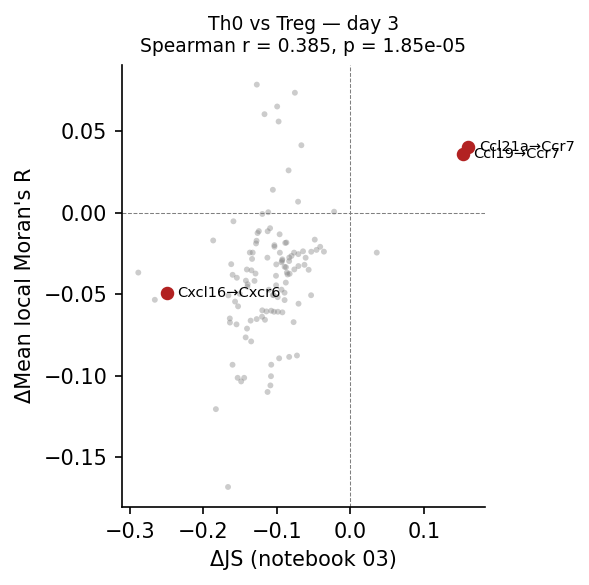

In [39]:
pairs_treg = [('Ccl19','Ccr7'), ('Ccl21a','Ccr7'), ('Cxcl13','Cxcr5'), ('Ccl20','Ccr6'),
              ('Cxcl16','Cxcr6'), ('Ccl3','Ccr5'), ('Ccl4','Ccr5'), ('Il2','Il2ra')]

fig, merged_treg, r_treg = compare_js_morans(
    js_treg_d3, dm_treg_d3,
    title='Th0 vs Treg — day 3',
    pairs_to_label=pairs_treg)
plt.savefig(os.path.join(plot_out_dir, 'compare_JS_morans_Th0vTreg_d3.pdf'),
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

103 shared pairs for Th0 vs Th17 — day 3


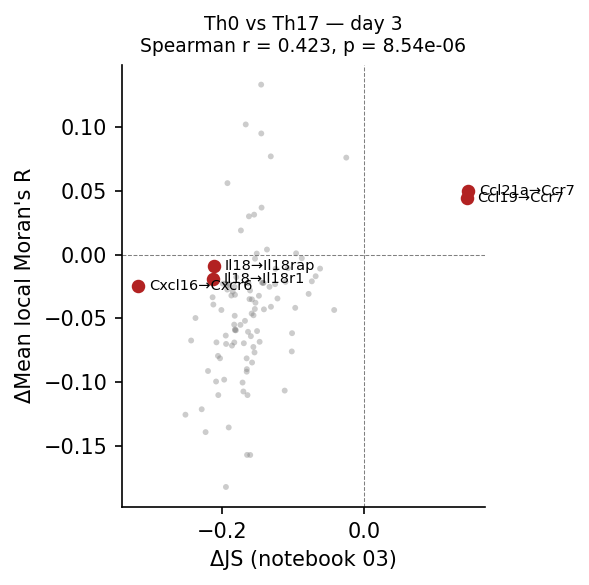

In [40]:
pairs_th17 = [('Ccl19','Ccr7'), ('Ccl21a','Ccr7'), ('Cxcl13','Cxcr5'),
              ('Cxcl16','Cxcr6'), ('Il18','Il18r1'), ('Il18','Il18rap'), ('Ccl4','Ccr5')]

fig, merged_th17, r_th17 = compare_js_morans(
    js_th17_d3, dm_th17_d3,
    title='Th0 vs Th17 — day 3',
    pairs_to_label=pairs_th17)
plt.savefig(os.path.join(plot_out_dir, 'compare_JS_morans_Th0vTh17_d3.pdf'),
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [43]:
# print('Spearman r between ΔJS and ΔMean local Moran\'s R:')
# print(f'  Th0 vs Th2  day3:  r = {r_th2:.3f}')
# print(f'  Th0 vs Treg day3:  r = {r_treg:.3f}')
# print(f'  Th0 vs Th17 day3:  r = {r_th17:.3f}')
# print(f'  Th0 vs Th2  day30: r = {r_th2_d30:.3f}')

## Spatial visualization of local scores

Plot local bivariate Moran's R scores on the tissue for key L-R pairs.

In [ ]:
# Example: Ccl19 -> Ccr7 local scores in day3 sample
# The local scores live in res_d3.obsm or res_d3.layers — adjust key based on inspection above
# sc.pl.embedding(ad_d3, basis='spatial', color=<local_score_col>, frameon=False)
# Adjust once the output structure is confirmed

In [ ]:
import session_info
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()